<a href="https://colab.research.google.com/github/praveenm-web/NASSCOM/blob/main/Day5_U13_%E2%80%94_Optimization_(Part_1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_energy(csv_path="energy_consumption.csv", seed=5, verbose=False):
    """Clean regression dataset for coding gradient descent from scratch:
    predict a building's daily energy use (kWh).

    - 'floor_area_sqft' has a strong, mostly-linear relationship with energy
      (ideal for the single-feature loss-bowl demo).
    - 'occupancy' is on a very different scale from floor_area, so the two
      together make the feature-scaling-speeds-optimization demo land clearly.
    """
    rng = np.random.default_rng(seed)
    N = 600

    floor_area = np.clip(rng.normal(2200, 900, N), 300, 6000).round(0)   # ~100s-1000s
    occupancy = np.clip(rng.normal(25, 12, N), 1, 80).round(0)           # ~tens
    avg_temp_c = np.clip(rng.normal(24, 6, N), 8, 42).round(1)
    insulation = rng.integers(1, 6, N)                                   # 1 (poor) .. 5 (great)

    # daily energy (kWh): dominated by floor area, plus occupancy & cooling load
    energy = (1.05 * floor_area
              + 18.0 * occupancy
              + 35.0 * np.clip(avg_temp_c - 22, 0, None)   # cooling above 22C
              - 60.0 * insulation
              + rng.normal(0, 120, N))
    energy = np.clip(energy, 50, None).round(1)

    df = pd.DataFrame({
        "building_id": [f"BLD{i+1:04d}" for i in range(N)],
        "floor_area_sqft": floor_area.astype(int),
        "occupancy": occupancy.astype(int),
        "avg_temp_c": avg_temp_c,
        "insulation_score": insulation,
        "energy_kwh": energy,
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("energy:", df.shape)
        print("corr(area, energy):", round(df["floor_area_sqft"].corr(df["energy_kwh"]), 3))
        print("energy range:", df["energy_kwh"].min(), "-", df["energy_kwh"].max())
    return df

if not os.path.exists('energy_consumption.csv'):
    build_energy(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Generated dataset file.


In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('energy_consumption.csv')
print('shape:', df.shape)
df.head(3)

shape: (600, 6)


,building_id,floor_area_sqft,occupancy,avg_temp_c,insulation_score,energy_kwh
0,BLD0001,1478,49,28.0,4,2206.6
1,BLD0002,1008,16,8.0,1,1258.1
2,BLD0003,1976,27,21.4,1,2221.9


1. The problem and the loss function

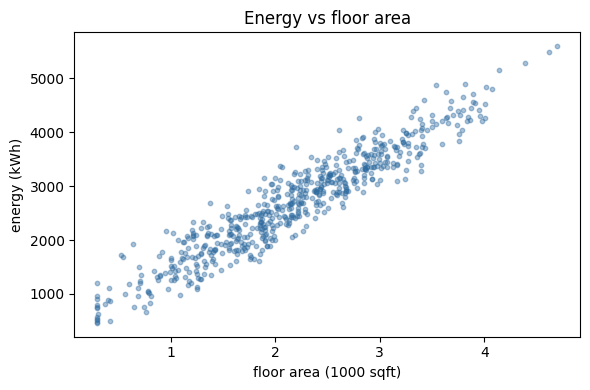

MSE at w=0, b=0: 8176582.4


In [3]:
# -----------------------------------------------------------
# 🔹 1A. ONE FEATURE: floor_area -> energy_kwh
# -----------------------------------------------------------
# Work in thousands of sqft so the numbers are friendly.
x = df['floor_area_sqft'].values / 1000.0      # feature
y = df['energy_kwh'].values                    # target

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, s=10, alpha=0.4, color='#2D6A9F')
ax.set_xlabel('floor area (1000 sqft)'); ax.set_ylabel('energy (kWh)')
ax.set_title('Energy vs floor area'); plt.tight_layout(); plt.show()

def mse(w, b):
    pred = w * x + b
    return np.mean((y - pred) ** 2)
print('MSE at w=0, b=0:', round(mse(0, 0), 1))

2. The loss landscape (the 'bowl')

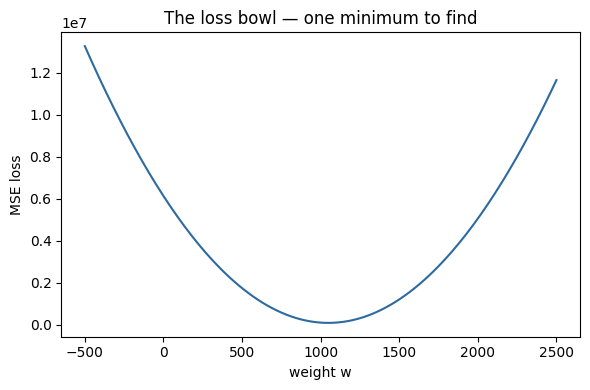

The curve is convex: a single lowest point gradient descent can reach.


In [4]:
# -----------------------------------------------------------
# 🔹 2A. SWEEP THE WEIGHT w (fix b) AND PLOT THE LOSS
# -----------------------------------------------------------
b_fixed = y.mean() - 1.05 * x.mean() * 1000   # a reasonable intercept
ws = np.linspace(-500, 2500, 200)
losses = [mse(w, b_fixed) for w in ws]
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ws, losses, color='#2D6A9F')
ax.set_xlabel('weight w'); ax.set_ylabel('MSE loss')
ax.set_title('The loss bowl — one minimum to find')
plt.tight_layout(); plt.show()
print('The curve is convex: a single lowest point gradient descent can reach.')

3. Gradient descent from scratch

In [5]:
# -----------------------------------------------------------
# 🔹 3A. THE GRADIENTS OF MSE, THEN THE UPDATE LOOP
# -----------------------------------------------------------
# MSE = mean((y - (w*x+b))^2)
#   dL/dw = -2 * mean(x * (y - pred))
#   dL/db = -2 * mean(    (y - pred))
def gradients(w, b):
    pred = w * x + b
    err = y - pred
    dw = -2 * np.mean(x * err)
    db = -2 * np.mean(err)
    return dw, db

def gradient_descent(lr=0.1, epochs=100):
    w, b = 0.0, 0.0
    history = []
    for _ in range(epochs):
        dw, db = gradients(w, b)
        w -= lr * dw          # the update rule:  theta <- theta - lr * grad
        b -= lr * db
        history.append(mse(w, b))
    return w, b, history

w, b, hist = gradient_descent(lr=0.1, epochs=100)
print(f'learned: w={w:.1f}, b={b:.1f}')
print(f'loss: {hist[0]:.0f} (start) -> {hist[-1]:.0f} (end)')

learned: w=1042.9, b=426.2
loss: 699089 (start) -> 94737 (end)


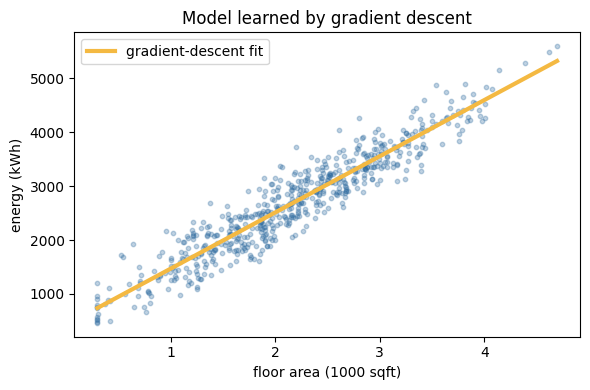

In [6]:
# Plot the fitted line over the data
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, s=10, alpha=0.3, color='#2D6A9F')
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, w * xs + b, color='#F4B942', lw=3, label='gradient-descent fit')
ax.set_xlabel('floor area (1000 sqft)'); ax.set_ylabel('energy (kWh)')
ax.legend(); ax.set_title('Model learned by gradient descent')
plt.tight_layout(); plt.show()

In [7]:
# 1. gradients at the start
w_start, b_start = 0.0, 0.0
dw_start, db_start = gradients(w_start, b_start)
print(f'Gradients at start (w={w_start}, b={b_start}): dw={dw_start:.2f}, db={db_start:.2f}')

# 2. one manual update step (lr=0.1)
lr = 0.1
w_one_step = w_start - lr * dw_start
b_one_step = b_start - lr * db_start
print(f'After one step (lr={lr}): w={w_one_step:.2f}, b={b_one_step:.2f}')

# 3. show the loss dropped
loss_start = mse(w_start, b_start)
loss_one_step = mse(w_one_step, b_one_step)
print(f'Loss at start: {loss_start:.0f}')
print(f'Loss after one step: {loss_one_step:.0f} (dropped by {loss_start - loss_one_step:.0f})')

Gradients at start (w=0.0, b=0.0): dw=-13293.91, db=-5395.34
After one step (lr=0.1): w=1329.39, b=539.53
Loss at start: 8176582
Loss after one step: 699089 (dropped by 7477493)


4. The loss curve over epochs

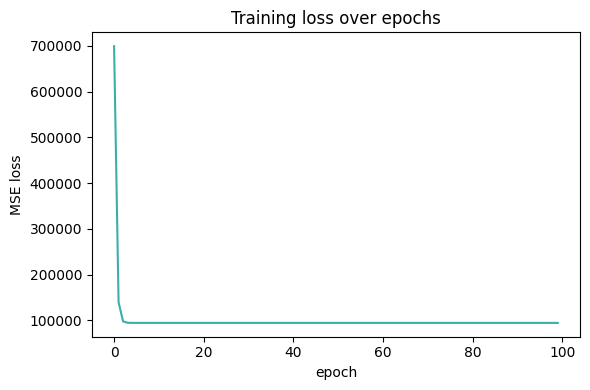

Steep early improvement, then a flat tail = converged.


In [8]:
# -----------------------------------------------------------
# 🔹 4A. LOSS SHOULD FALL FAST, THEN FLATTEN (convergence)
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(hist, color='#3AAFA9')
ax.set_xlabel('epoch'); ax.set_ylabel('MSE loss')
ax.set_title('Training loss over epochs'); plt.tight_layout(); plt.show()
print('Steep early improvement, then a flat tail = converged.')

5. The learning rate: too small, just right, too large

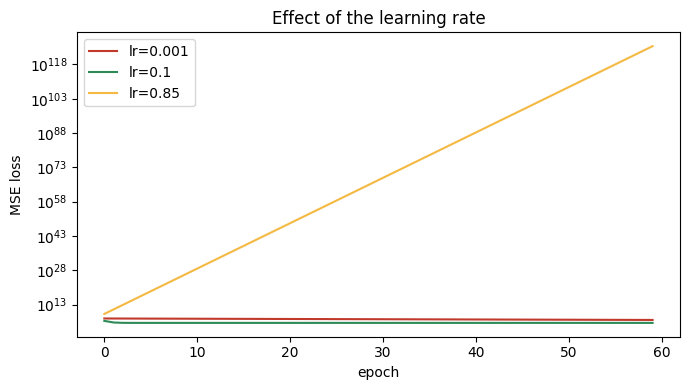

Too small (red): crawls. Good (green): fast & stable. Too large (gold): unstable.


In [9]:
# -----------------------------------------------------------
# 🔹 5A. RUN GD AT THREE LEARNING RATES
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))
for lr, col in [(0.001, '#C0392B'), (0.1, '#2E8B57'), (0.85, '#F4B942')]:
    _, _, h = gradient_descent(lr=lr, epochs=60)
    ax.plot(h, label=f'lr={lr}', color=col)
ax.set_xlabel('epoch'); ax.set_ylabel('MSE loss'); ax.legend()
ax.set_title('Effect of the learning rate'); ax.set_yscale('log')
plt.tight_layout(); plt.show()
print('Too small (red): crawls. Good (green): fast & stable. Too large (gold): unstable.')

In [11]:
# 1. run with an overly large lr
exploding_lr = 1.5  # An intentionally large learning rate
_, _, h_explode = gradient_descent(lr=exploding_lr, epochs=60)

# 2. print the final loss (expect explosion)
print(f'Final loss with lr={exploding_lr}: {h_explode[-1]:.0e}')

# 3. Why it diverges: ...   (comment)
# When the learning rate is too large, the optimizer takes steps that are too big,
# overshooting the minimum of the loss function and actually increasing the loss
# with each iteration, leading to divergence (loss 'explodes' to infinity or NaN).

Final loss with lr=1.5: 7e+157


6. Why feature scaling speeds up optimization

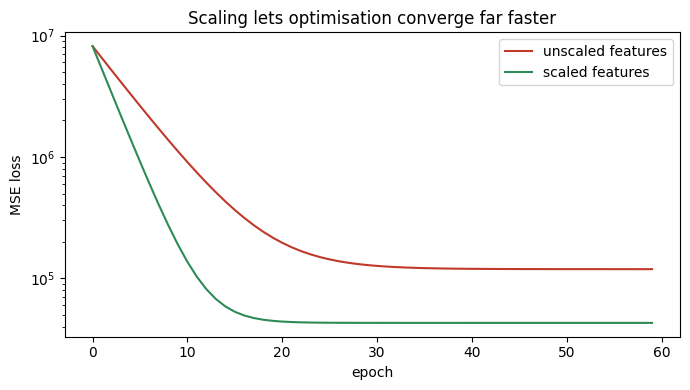

In [12]:
# -----------------------------------------------------------
# 🔹 6A. TWO FEATURES ON VERY DIFFERENT SCALES
# -----------------------------------------------------------
# floor_area (hundreds-thousands) and occupancy (tens) -> a stretched loss bowl.
X2 = df[['floor_area_sqft', 'occupancy']].values.astype(float)
yv = df['energy_kwh'].values

def gd_multi(Xm, lr=0.01, epochs=60):
    n, d = Xm.shape
    w = np.zeros(d); b = 0.0; hist = []
    for _ in range(epochs):
        pred = Xm @ w + b
        err = yv - pred
        w += lr * (2 / n) * (Xm.T @ err)
        b += lr * (2 / n) * err.sum()
        hist.append(np.mean(err ** 2))
    return hist

from sklearn.preprocessing import StandardScaler
X2s = StandardScaler().fit_transform(X2)
h_raw = gd_multi(X2, lr=1e-8, epochs=60)     # raw needs a tiny lr or it explodes
h_scaled = gd_multi(X2s, lr=0.1, epochs=60)  # scaled tolerates a healthy lr

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(h_raw, label='unscaled features', color='#C0392B')
ax.plot(h_scaled, label='scaled features', color='#2E8B57')
ax.set_xlabel('epoch'); ax.set_ylabel('MSE loss'); ax.legend(); ax.set_yscale('log')
ax.set_title('Scaling lets optimisation converge far faster')
plt.tight_layout(); plt.show()

In [13]:
# 1. final losses
print(f'Final loss with unscaled features: {h_raw[-1]:.0f}')
print(f'Final loss with scaled features: {h_scaled[-1]:.0f}')

# 2. Why unscaled needs a tiny lr: ...   (comment)
# Unscaled features often have vastly different ranges and magnitudes.
# This creates a 'stretched' loss landscape with narrow, steep valleys and wide, flat areas.
# A large learning rate would cause oscillations or divergence in the steep dimensions,
# while a very small learning rate is needed to carefully navigate these landscapes.
# Scaling transforms the features to a similar range, making the loss landscape more spherical,
# allowing for larger, more stable learning rates and faster convergence.

Final loss with unscaled features: 119138
Final loss with scaled features: 43005


7. Sanity-check against scikit-learn

In [14]:
# -----------------------------------------------------------
# 🔹 7A. DID OUR HAND-CODED GD FIND THE RIGHT ANSWER?
# -----------------------------------------------------------
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression().fit(x.reshape(-1, 1), y)
print(f'gradient descent : w={w:.1f}, b={b:.1f}')
print(f'scikit-learn     : w={lr_model.coef_[0]:.1f}, b={lr_model.intercept_:.1f}')
print('They should be very close — our optimiser reached the same minimum.')

gradient descent : w=1042.9, b=426.2
scikit-learn     : w=1042.8, b=426.5
They should be very close — our optimiser reached the same minimum.


In [15]:
# 1. sklearn prediction for 3000 sqft
sqft_to_predict = 3000
x_input_sklearn = sqft_to_predict / 1000.0
sklearn_pred = lr_model.predict(np.array([[x_input_sklearn]]))[0]
print(f'Sklearn prediction for {sqft_to_predict} sqft: {sklearn_pred:.1f} kWh')

# 2. your-GD prediction, and compare
# w and b are from the gradient_descent function earlier
your_gd_pred = w * x_input_sklearn + b
print(f'Your GD prediction for {sqft_to_predict} sqft: {your_gd_pred:.1f} kWh')
print(f'Difference: {abs(sklearn_pred - your_gd_pred):.1f} kWh')

Sklearn prediction for 3000 sqft: 3554.8 kWh
Your GD prediction for 3000 sqft: 3554.9 kWh
Difference: 0.1 kWh
